# Building and validating consistency check code
Helper workbook for building and testing functions in consistency_metrics.py

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
from collections import defaultdict

PROJECT_ROOT = Path("..").resolve()
RUNS_DIR = PROJECT_ROOT / "output_data" / "runs"
NEG_RUNS_DIR = PROJECT_ROOT / "consistency_checks" / "output_data_negation" / "runs"

In [3]:
records = []

for run_dir in sorted(RUNS_DIR.glob("*")):
    json_path = run_dir / "full_results.json"
    if not json_path.exists():
        continue

    with open(json_path) as f:
        data = json.load(f)

    run_id = run_dir.name
    config = data["run_metadata"]["config_used"]
    model = config["llm_settings"]["model"]

    for step in data["results_per_step"]:
        step_name = step["step_name"]
        for task in step["results_per_task"]:
            task_name = task["task_name"]
            final_round = task["rounds_data"][-1]
            responses = final_round["responses"]

            # Collect all percentile_* values from parsed_estimation across experts
            percentile_lists = defaultdict(list)
            for r in responses:
                pe = r.get("parsed_estimation", {})
                for key, val in pe.items():
                    if key.startswith("percentile_") and isinstance(val, (int, float)):
                        percentile_lists[key].append(val)

            record = {
                "run_id": run_id,
                "model": model,
                "step_name": step_name,
                "task_name": task_name,
                "n_experts": len(responses),
                "final_prob": task["final_aggregated_probability"],
            }
            for key, vals in sorted(percentile_lists.items()):
                record[key] = vals
                record[f"{key}_mean"] = np.mean(vals) if vals else np.nan

            records.append(record)

df = pd.DataFrame(records)
print(f"Loaded {len(df)} records from {df['run_id'].nunique()} runs")

percentile_cols = sorted(c for c in df.columns if c.startswith("percentile_") and not c.endswith("_mean"))
mean_cols = [f"{c}_mean" for c in percentile_cols]
display(df[["run_id", "model", "step_name", "task_name", "n_experts"] + percentile_cols + mean_cols].head(5))


Loaded 24 records from 8 runs


,run_id,model,step_name,task_name,n_experts,percentile_25th,percentile_50th,percentile_75th,percentile_25th_mean,percentile_50th_mean,percentile_75th_mean
0,20260301_165010,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,1,[0.61],[0.65],[0.7],0.61,0.65,0.70
1,20260301_165010,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,1,[0.5],[0.55],[0.6],0.50,0.55,0.60
2,20260301_165010,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,1,[0.85],[0.87],[0.89],0.85,0.87,0.89
3,20260301_165252,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,1,[0.6],[0.63],[0.67],0.60,0.63,0.67
4,20260301_165252,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,1,[0.52],[0.57],[0.62],0.52,0.57,0.62


## Changing w1 implementation and adding w2
I want the w1 implementation to use lists of values rather than expecting specific keys. I've made that change and now want to test it with some real and arbitrary data to make sure it's working.

I also added a w2 implementation using the same approach. These seem to both be working.

In [4]:
from consistency_metrics import w1_distance, w2_distance, w1_distance_beta, w2_distance_beta, plot_cdf_pairs, plot_pdf_pairs
import itertools
subset = df[
    #(df["model"] == "claude-sonnet-4-6" )  &
    (df["step_name"] == "TA0001 - Initial Access")
]

def row_to_pairs(row):
    pattern = re.compile(r'percentile_(\d+)th_mean')
    pairs = []
    for col in row.index:
        m = pattern.search(col)
        if m:
            pct = int(m.group(1)) / 100.0
            pairs.append((pct, row[col]))
    return sorted(pairs)

rows = subset.reset_index(drop=True)
for (i, row_a), (j, row_b) in itertools.combinations(rows.iterrows(), 2):
    a = row_to_pairs(row_a)
    b = row_to_pairs(row_b)
    model_a = row_a.model
    model_b = row_b.model
    dists = [a,b]
    distance1 = w1_distance(a, b)
    distance1_b = w1_distance_beta(a, b)
    distance2 = w2_distance(a,b)
    distance2_b = w2_distance_beta(a,b)
    print(f"  a = {a}")
    print(f"  b = {b}")
    print(f"{model_a} vs {model_b}: W1 = {distance1:.4f}")
    print(f"{model_a} vs {model_b}: W1_beta = {distance1_b:.4f}")
    print(f"{model_a} vs {model_b}: W2 = {distance2:.4f}")
    print(f"{model_a} vs {model_b}: W2_beta = {distance2_b:.4f}")
    # fig1 = plot_cdf_pairs(dists, use_beta=True)
    # fig2 = plot_pdf_pairs(dists,use_beta=True)
    # fig1 = plot_cdf_pairs(dists)
    # fig2 = plot_pdf_pairs(dists)


  a = [(0.25, 0.61), (0.5, 0.65), (0.75, 0.7)]
  b = [(0.25, 0.6), (0.5, 0.63), (0.75, 0.67)]
claude-sonnet-4-6 vs claude-sonnet-4-6: W1 = 0.0150
claude-sonnet-4-6 vs claude-sonnet-4-6: W1_beta = 0.0209
claude-sonnet-4-6 vs claude-sonnet-4-6: W2 = 0.0173
claude-sonnet-4-6 vs claude-sonnet-4-6: W2_beta = 0.0241
  a = [(0.25, 0.61), (0.5, 0.65), (0.75, 0.7)]
  b = [(0.25, 0.61), (0.5, 0.66), (0.75, 0.71)]
claude-sonnet-4-6 vs claude-sonnet-4-6: W1 = 0.0050
claude-sonnet-4-6 vs claude-sonnet-4-6: W1_beta = 0.0081
claude-sonnet-4-6 vs claude-sonnet-4-6: W2 = 0.0065
claude-sonnet-4-6 vs claude-sonnet-4-6: W2_beta = 0.0096
  a = [(0.25, 0.61), (0.5, 0.65), (0.75, 0.7)]
  b = [(0.25, 0.61), (0.5, 0.64), (0.75, 0.68)]
claude-sonnet-4-6 vs claude-sonnet-4-6: W1 = 0.0075
claude-sonnet-4-6 vs claude-sonnet-4-6: W1_beta = 0.0143
claude-sonnet-4-6 vs claude-sonnet-4-6: W2 = 0.0100
claude-sonnet-4-6 vs claude-sonnet-4-6: W2_beta = 0.0172
  a = [(0.25, 0.61), (0.5, 0.65), (0.75, 0.7)]
  b = [(0.25, 0

In [5]:
# Direct test with explicit (percentile, value) pairs — more points than just quartiles
a = [(0.1, 0.05), (0.25, 0.2), (0.5, 0.4), (0.75, 0.7), (0.9, 0.85)]
b = [(0.25, 0.3), (0.5, 0.5), (0.75, 0.6)]  # different number of points

print(f"W1 (mismatched breakpoints) = {w1_distance(a, b):.4f}")
print(f"W1 (mismatched breakpoints) beta = {w1_distance_beta(a, b):.4f}")
print(f"W2 (mismatched breakpoints) = {w2_distance(a, b):.4f}")
print(f"W2 (mismatched breakpoints) beta = {w2_distance_beta(a, b):.4f}")



W1 (mismatched breakpoints) = 0.0625
W1 (mismatched breakpoints) beta = 0.0902
W2 (mismatched breakpoints) = 0.0718
W2 (mismatched breakpoints) beta = 0.1001


In [6]:
# Checking functions with unit tests
# note this implementation has an important consideration, which is that I'm enforcing bounds at 0 and 1 to make the cdf sensible. 
print("Should output 0")
a = [(0.25, 0.2), (0.5, 0.5), (0.75, 0.8)]
b = [(0.25, 0.2), (0.5, 0.5), (0.75, 0.8)]
print(f"W1 = {w1_distance(a, b):.4f}")
print(f"W1 beta = {w1_distance_beta(a, b):.4f}")
print(f"W2 = {w2_distance(a, b):.4f}")
print(f"W2 beta = {w2_distance_beta(a, b):.4f}")

#should output W1 = 0.15, W2 = ~0.163
print("W1 = 0.15, W2 = 0.163")
a = [(0.25, 0.25), (0.5, 0.5), (0.75, 0.75)]
b = [(0.25, 0.45), (0.5, 0.7), (0.75, 0.95)]

print(f"W1 = {w1_distance(a, b):.4f}")
print(f"W1 beta = {w1_distance_beta(a, b):.4f}")
print(f"W2 = {w2_distance(a, b):.4f}")
print(f"W2 beta = {w2_distance_beta(a, b):.4f}")



Should output 0
W1 = 0.0000
W1 beta = 0.0000
W2 = 0.0000
W2 beta = 0.0000
W1 = 0.15, W2 = 0.163
W1 = 0.1500
W1 beta = 0.1587
W2 = 0.1633
W2 beta = 0.1717


In [7]:
from consistency_metrics import compute_pairwise_metrics
import itertools
subset_cl = df[
    (df["model"] == "claude-sonnet-4-6" )  &
    (df["step_name"] == "TA0001 - Initial Access")
]

subset_gpt = df[
    (df["model"] == "gpt-5-mini-2025-08-07" )  &
    (df["step_name"] == "TA0001 - Initial Access")
]

results = compute_pairwise_metrics(subset_cl, subset_gpt)
print(pd.Series(results))

results = compute_pairwise_metrics(subset_cl)
print(pd.Series(results))

w1                 0.060583
w2                 0.072959
p50_divergence     0.047500
iqr_divergence     0.215000
n_pairs           16.000000
dtype: float64
w1                0.011250
w2                0.013650
p50_divergence    0.016667
iqr_divergence    0.018333
n_pairs           6.000000
dtype: float64


In [10]:
from consistency_metrics import compute_pairwise_results
import itertools
subset_cl = df[
    (df["model"] == "claude-sonnet-4-6" )  &
    (df["step_name"] == "TA0001 - Initial Access")
]

subset_gpt = df[
    (df["model"] == "gpt-5-mini-2025-08-07" )  &
    (df["step_name"] == "TA0001 - Initial Access")
]

results = compute_pairwise_results(subset_cl, subset_gpt)

print(results)

results = compute_pairwise_results(subset_cl)
print(results)

    idx_a  idx_b        w1        w2  p50_divergence  iqr_divergence
0       0     12  0.042500  0.057591            0.05            0.12
1       0     15  0.081047  0.093630            0.03            0.32
2       0     18  0.050682  0.060553            0.05            0.18
3       0     21  0.055577  0.064161            0.04            0.21
4       3     12  0.057500  0.074274            0.07            0.14
5       3     15  0.087778  0.100083            0.05            0.34
6       3     18  0.060208  0.074610            0.07            0.20
7       3     21  0.063929  0.075939            0.06            0.23
8       6     12  0.037500  0.051478            0.04            0.11
9       6     15  0.077988  0.090967            0.02            0.31
10      6     18  0.046500  0.055227            0.04            0.17
11      6     21  0.051875  0.059722            0.03            0.20
12      9     12  0.050000  0.067577            0.06            0.14
13      9     15  0.086778  0.0993

W1 (mismatched breakpoints) = 0.0625
W1 (mismatched breakpoints) beta = 0.0902


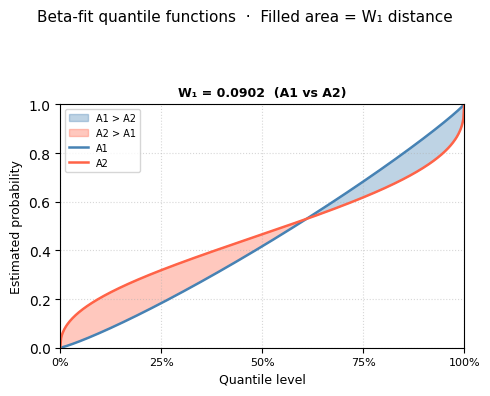

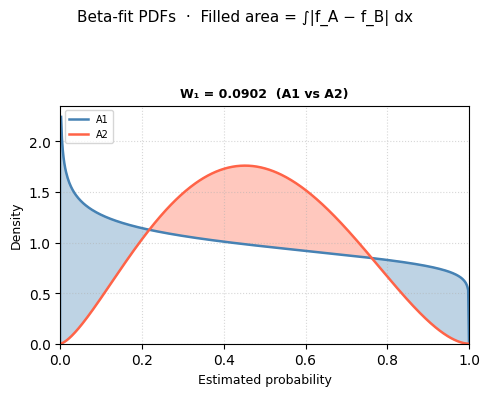

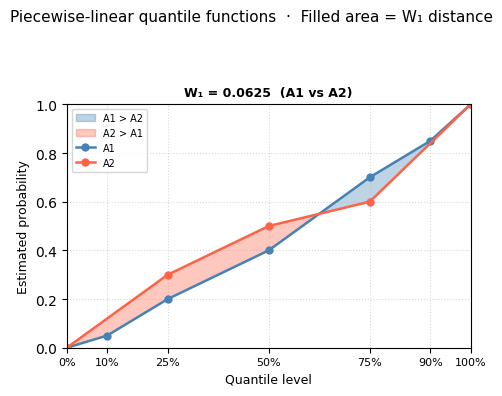

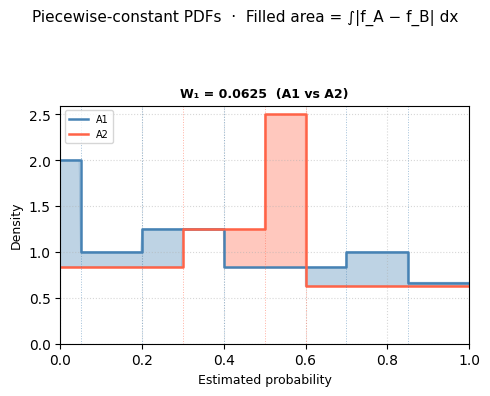

In [4]:

a = [(0.1, 0.05), (0.25, 0.2), (0.5, 0.4), (0.75, 0.7), (0.9, 0.85)]
b = [(0.25, 0.3), (0.5, 0.5), (0.75, 0.6)]
dists = [a,b]
fig1 = plot_cdf_pairs(dists, use_beta=True)
fig2 = plot_pdf_pairs(dists,use_beta=True)
fig1 = plot_cdf_pairs(dists)
fig2 = plot_pdf_pairs(dists)
print(f"W1 (mismatched breakpoints) = {w1_distance(a, b):.4f}")
print(f"W1 (mismatched breakpoints) beta = {w1_distance_beta(a, b):.4f}")
